This is coding part of project pitch for CSE 572 Data Mining Course.
Trainig data has been taken taken from Kaggle and from below link.
https://www.kaggle.com/c/playground-series-s4e10.

In [611]:
# Core libraries
import os
import joblib
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Model evaluation & splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import permutation_importance

# Typing and structure
from dataclasses import dataclass
from typing import Dict, Tuple


In [612]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", palette="muted")

In [613]:
# print(os.getcwd())
df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()


(58645, 13)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [614]:
df.info()
df.isna().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


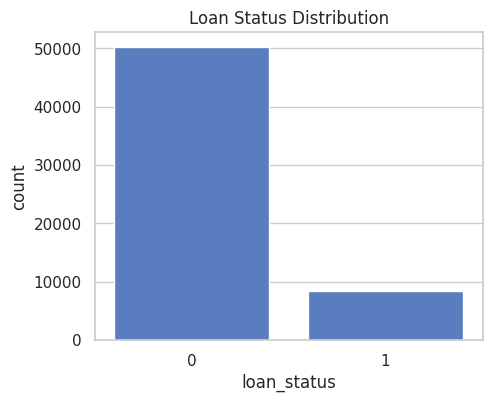

In [615]:
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

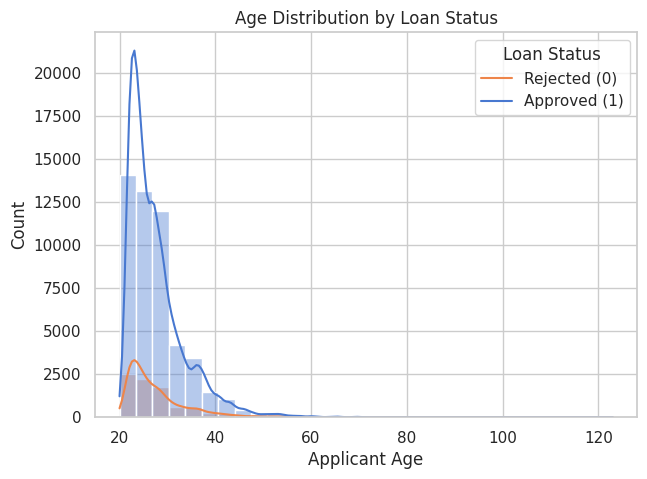

In [616]:
# Age distribution
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="person_age", hue="loan_status", bins=30, kde=True, alpha=0.4)
plt.title("Age Distribution by Loan Status")
plt.xlabel("Applicant Age")
plt.ylabel("Count")
plt.legend(title="Loan Status", labels=["Rejected (0)", "Approved (1)"])
plt.show()

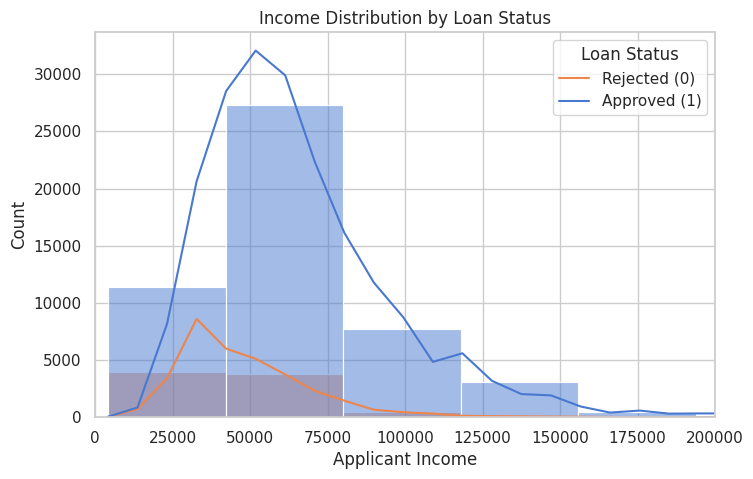

In [617]:
# Income distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="person_income", hue="loan_status", bins=50, kde=True, alpha=0.5)
plt.title("Income Distribution by Loan Status")
plt.xlabel("Applicant Income")
plt.ylabel("Count")
plt.xlim(0, 200000)  # focus on the main range, avoids extreme outliers
plt.legend(title="Loan Status", labels=["Rejected (0)", "Approved (1)"])
plt.show()


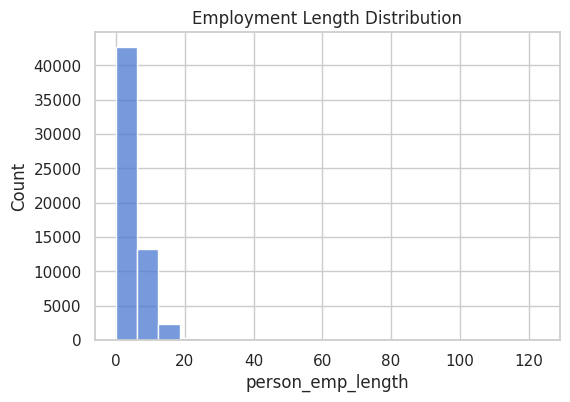

In [618]:
# Employment length distribution
plt.figure(figsize=(6,4))
sns.histplot(df["person_emp_length"], bins=20, kde=False)
plt.title("Employment Length Distribution")
plt.show()

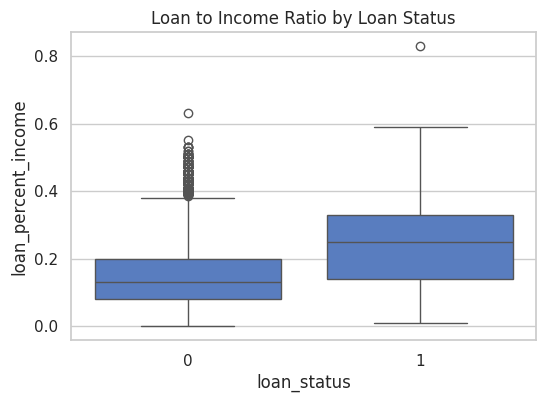

In [619]:
# Loan percent income by approval status
plt.figure(figsize=(6,4))
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title("Loan to Income Ratio by Loan Status")
plt.show()

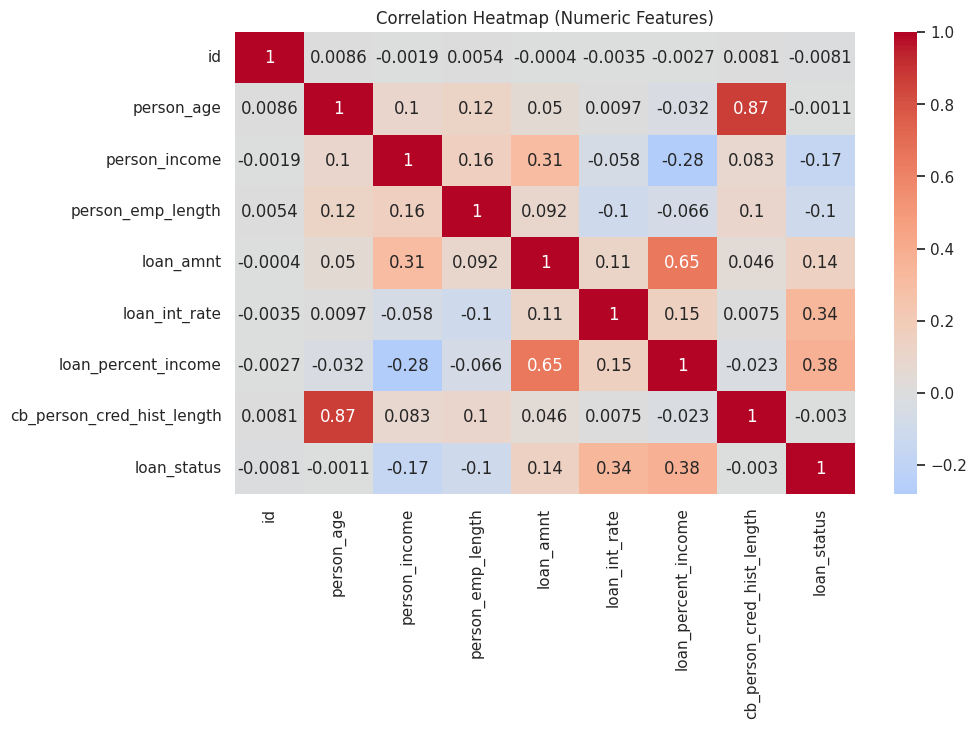

In [620]:
# Correlation heatmap
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


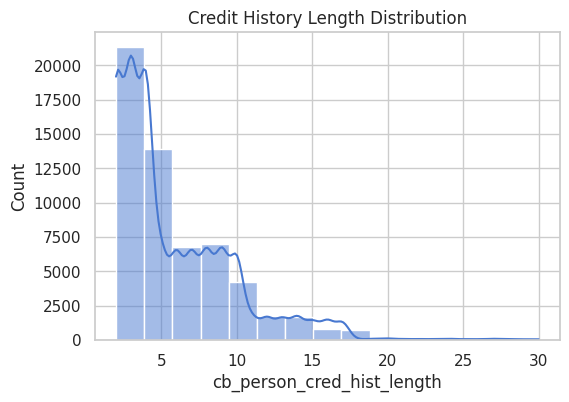

In [621]:
# Credit history length distribution
plt.figure(figsize=(6,4))
sns.histplot(df["cb_person_cred_hist_length"], bins=15, kde=True)
plt.title("Credit History Length Distribution")
plt.show()

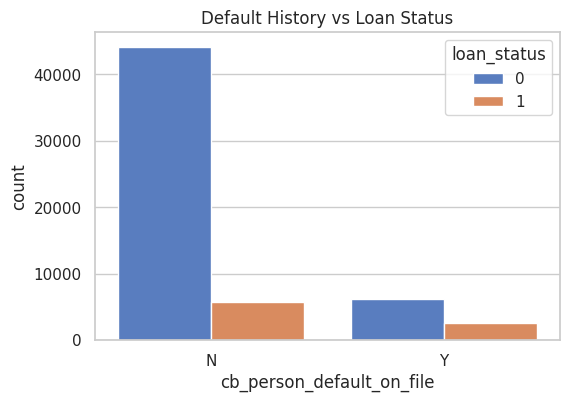

In [622]:
# Credit default history vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x="cb_person_default_on_file", hue="loan_status", data=df)
plt.title("Default History vs Loan Status")
plt.show()

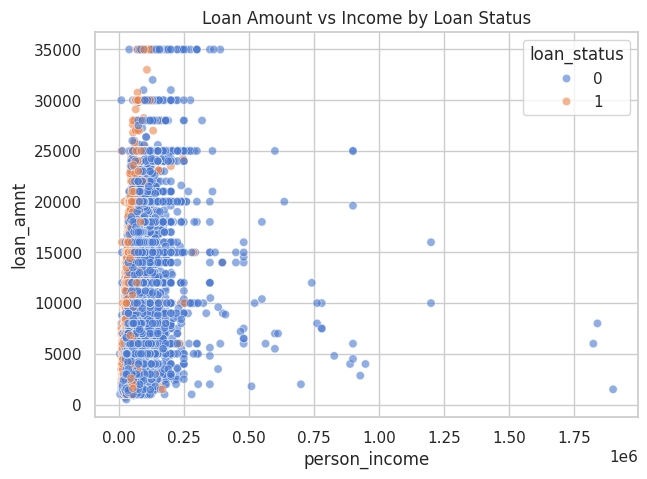

In [623]:
# Loan amount vs income (scatter)
plt.figure(figsize=(7,5))
sns.scatterplot(x="person_income", y="loan_amnt", hue="loan_status", data=df, alpha=0.6)
plt.title("Loan Amount vs Income by Loan Status")
plt.show()

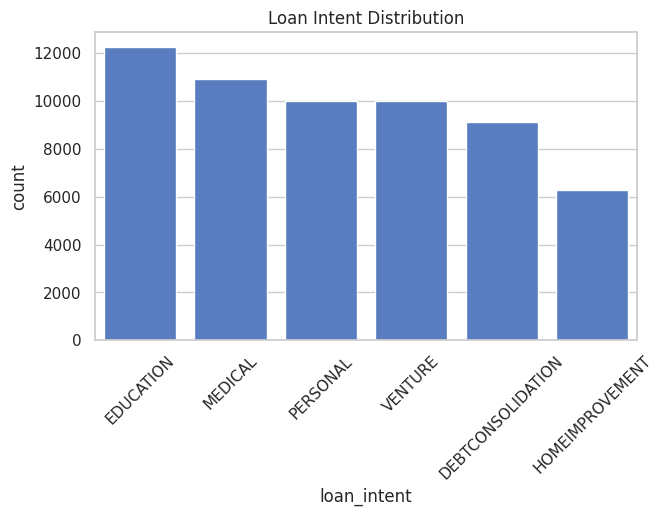

In [624]:
# Loan intent counts
plt.figure(figsize=(7,4))
sns.countplot(x="loan_intent", data=df, order=df["loan_intent"].value_counts().index)
plt.title("Loan Intent Distribution")
plt.xticks(rotation=45)
plt.show()

EDA and FE Part

In [625]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,58645.0,29322.000000,16929.497605,0.00,14661.00,29322.00,43983.00,58644.00
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00


Replaced age with 26.0


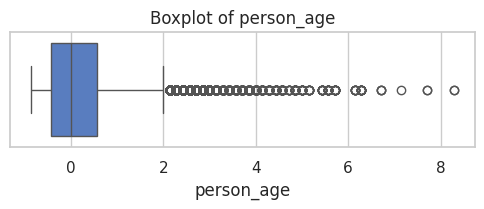

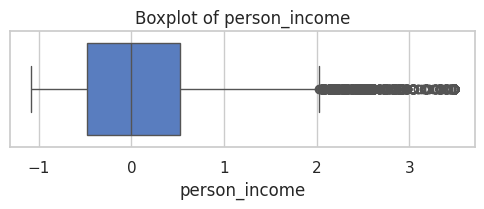

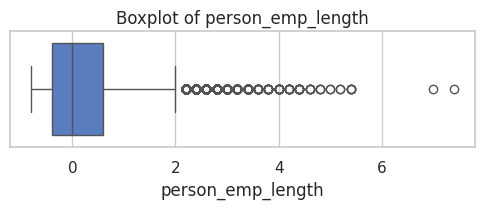

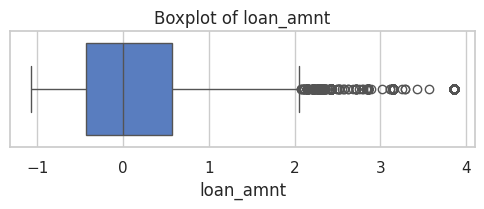

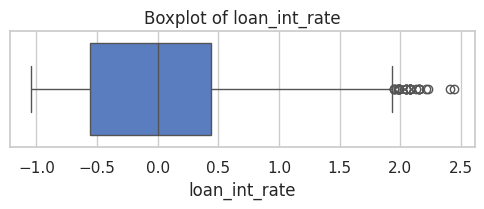

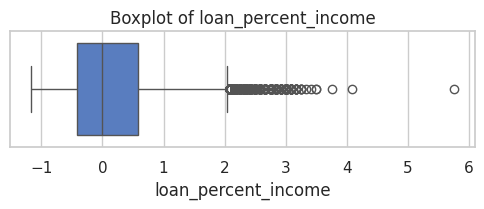

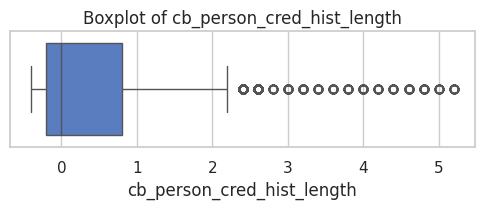

In [626]:
# df.isnull().sum() # checked there is no missing values, so no need to handle them

# df.head(5)

# id	person_age	person_income	person_home_ownership	person_emp_length	loan_intent	loan_grade	loan_amnt	loan_int_rate	loan_percent_income	cb_person_default_on_file	cb_person_cred_hist_length	loan_status
# 0	0	37	35000	RENT	0.0	EDUCATION	B	6000	11.49	0.17	N	14	0
# 1	1	22	56000	OWN	6.0	MEDICAL	C	4000	13.35	0.07	N	2	0
# 2	2	29	28800	OWN	8.0	PERSONAL	A	6000	8.90	0.21	N	10	0
# 3	3	30	70000	RENT	14.0	VENTURE	B	12000	11.11	0.17	N	5	0
# 4	4	22	60000	RENT	2.0	MEDICAL	A	6000	6.92	0.10	N	3	0

# df.columns 

# Index(['id', --nominal
# 'person_age', --ratio
# 'person_income', --ratio
# 'person_home_ownership', --nominal
# 'person_emp_length', --ratio
# 'loan_intent', --nominal
# 'loan_grade', --ordinal
# 'loan_amnt', --ratio
# 'loan_int_rate', --ratio
# 'loan_percent_income', --ratio
# 'cb_person_default_on_file', --nominal
# 'cb_person_cred_hist_length', --ratio
# 'loan_status'], --nominal (binary)
# dtype='object')


# df.nunique() # --selecting number of unique values in each column

# id                            58645 -- unique for each row
# person_age                       53 -- age in years
# person_income                  2641 -- income in dollars
# person_home_ownership             4  -- RENT, OWN, MORTGAGE, OTHER
# person_emp_length                36 -- employment length in years
# loan_intent                       6 -- EDUCATION, MEDICAL, PERSONAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION
# loan_grade                        7 -- A, B, C, D, E, F, G
# loan_amnt                       545 -- loan amount in dollars
# loan_int_rate                   362 -- interest rate in percentage
# loan_percent_income              61 -- percentage of income
# cb_person_default_on_file         2 -- Y, N
# cb_person_cred_hist_length       29 -- credit history length in years
# loan_status                       2   -- 0, 1
# dtype: int64


# df.describe().T
# count	mean	std	min	25%	50%	75%	max
# loan_int_rate	58645.0	10.677874	3.034697	5.42	7.88	10.75	12.99	23.22 (fine)
# loan_percent_income	58645.0	0.159238	0.091692	0.00	0.09	0.14	0.21	0.83 (fine)
# cb_person_cred_hist_length	58645.0	5.813556	4.029196	2.00	3.00	4.00	8.00	30.00 (fine)
# loan_amnt	58645.0	9217.556518	5563.807384	500.00	5000.00	8000.00	12000.00	35000.00 (fine)
# id	58645.0	29322.000000	16929.497605	0.00	14661.00	29322.00	43983.00	58644.00 (fine)

# DATA ISSUES IDENTIFIED:
# person_age	58645.0	27.550857	6.033216	20.00	23.00	26.00	30.00	123.00 (ISSUE WITH NOISE DATA)

# df[df['person_age'] > 75]

noisy = df.loc[df['id'] == 47336]

# define matching conditions (same categorical profile)
mask = (
    (df['person_home_ownership'] == noisy['person_home_ownership'].iloc[0]) &
    (df['loan_intent'] == noisy['loan_intent'].iloc[0]) &
    (df['loan_grade'] == noisy['loan_grade'].iloc[0]) &
    (df['person_income'].between(
        noisy['person_income'].iloc[0] * 0.9,
        noisy['person_income'].iloc[0] * 1.1))
)

similar = df[mask & (df['id'] != 47336)]

similar[['id','person_age','person_income','person_home_ownership','loan_intent','loan_grade']]

new_age = similar['person_age'].median()
df.loc[df['id'] == 47336, 'person_age'] = new_age
print(f"Replaced age with {new_age}")

# NOISE WITH AGE FIXED.
# person_income	58645.0	64046.172871	37931.106978	4200.00	42000.00	58000.00	75600.00	1,900,000.00 (outlier present)

# df[df['person_income'] > 350000].sort_values(by='person_income')
# 21238	21238	39	397800	RENT	5.0	PERSONAL	B	14000	11.48	0.03	N	9	1
# target person
# target_age = 39
# target_income = 397800

# # define margins
# age_margin = 5
# income_margin = 100000

# # filter
# similar_people = df[
#     (df['person_age'].between(target_age - age_margin, target_age + age_margin)) &
#     (df['person_income'].between(target_income - income_margin, target_income + income_margin))
# ]

# print(similar_people.shape[0], "similar people found.")

# # exclude the original record if you want
# # similar_people = similar_people[similar_people['id'] != 21238]

# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 2000)
# pd.set_option('display.colheader_justify', 'left')

# print(similar_people.to_string(index=False))


# Q1 = df['person_income'].quantile(0.25)
# Q3 = df['person_income'].quantile(0.75)
# IQR = Q3 - Q1

# # define bounds
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# # select outliers
# income_outliers = df[(df['person_income'] < lower) | (df['person_income'] > upper)]

# print(f"Outliers detected: {income_outliers.shape[0]}")
# income_outliers[['id', 'person_income']].head()

# df['person_income'].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

# OUTLIER FOR INCOME WILL NOT BE REMOVED AND JUST SCALED LATER BECAUSE IT MAY BE PERSON PROVIDED WRONG INFO AND THAT IS WHY THEY ARE BEEN REJECTED FOR LOAN

# person_emp_length	58645.0	4.701015	3.959784	0.00	2.00	4.00	7.00	123.00 (data noise in max value)

# df[df['person_emp_length'] > 30]

# Define realistic working start age
min_start_age = 15

# Filter unrealistic employment records
unrealistic_work = df[
    # (df['person_age'] > 22) &
    (df['person_emp_length'] > (df['person_age'] - min_start_age))
]

# Show results
unrealistic_work[['id', 'person_age', 'person_emp_length', 'person_income', 'loan_intent','loan_status']]
unrealistic_ids = unrealistic_work['id']
df = df[~df['id'].isin(unrealistic_ids)].copy()

df.describe().T

# df.info()

# df['id'].is_unique

num_cols = ['person_age','person_income','person_emp_length','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

lower, upper = df['person_income'].quantile([0.01, 0.99])
df['person_income'] = df['person_income'].clip(lower, upper)

df[num_cols] = RobustScaler().fit_transform(df[num_cols])

for col in num_cols:
    data = df[col].dropna()
    if data.empty:
        print(f"Skipping {col} — all values are NaN")
        continue
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=data)
    plt.title(f"Boxplot of {col}")
    plt.show()

# skew_values = df[num_cols].skew().sort_values(ascending=False)
# print("Skewness:\n", skew_values)

# person_income                 10.461966 # high skewness due to outliers
# person_age                     1.912113 # moderate skewness  
# cb_person_cred_hist_length     1.619086 # moderate skewness
# loan_amnt                      1.189137 # slight skewness
# person_emp_length              1.170056 # slight skewness
# loan_percent_income            0.917955 # fine
# loan_int_rate                  0.200000 # nearly symmetric


In [ ]:
# loan_status	58645.0	0.142382	0.349445	0.00	0.00	0.00	0.00	1.00 (imbalance present)
df['loan_status'].value_counts(normalize=True)

# For tree models (RandomForest, XGBoost)	class_weight='balanced'	Works great, no data duplication 
# For linear/logistic regression	Use class_weight='balanced'	Avoids scaling bias
# For small subsets or neural nets	Try SMOTE oversampling	Boosts recall for rare class
# For evaluation	Use roc_auc_score, recall, F1	Fair comparison metric

# | Dataset size       | Recommended technique                                           |
# | ------------------ | --------------------------------------------------------------- |
# | **< 10,000**       | Use **SMOTE** or hybrid oversampling                            |
# | **10,000–100,000** | Use **class_weight='balanced'**                                 |
# | **> 100,000**      | Consider model-specific weighting (LightGBM/XGBoost parameters) |


loan_status
0    0.857667
1    0.142333
Name: proportion, dtype: float64

In [628]:
# here i will start encoding categorical variables and scaling numerical ones
min_valid_income = df.loc[df['person_income'] > 0, 'person_income'].min()
df['person_income'] = df['person_income'].clip(lower=min_valid_income)
df['person_income_log'] = np.log1p(df['person_income'])

df['person_income_log'] = np.log1p(df['person_income'])
df['loan_amnt'] = df['loan_amnt'].clip(lower=1)
df['loan_amnt_log'] = np.log1p(df['loan_amnt'])
df['loan_percent_income'] = df['loan_percent_income'].clip(upper=1.0)

df["loan_stress"] = df["loan_amnt_log"] / df["person_income_log"]

cols_to_check = ['person_income_log','loan_amnt','loan_percent_income']
df[cols_to_check].skew()

# df.describe()

# df.loc[df['person_income_log'].isna(), 'person_income'].describe()

df['person_income_log'].isna().sum()



np.int64(0)

In [629]:
target_col = "loan_status"

num_cols = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "person_income_log",
    "loan_amnt_log",
    "loan_stress"
]
cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
]

random_state = 42
n_splits = 5

In [630]:
# TRAIN/TEST SPLIT
X = df[num_cols + cat_cols].copy()
y = df[target_col].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=random_state
)

In [631]:
# PREPROCESSING PIPELINE
num_transform = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]
cat_transform = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
]

preprocess = ColumnTransformer(
    transformers=[
        ("num",  StandardScaler(), num_cols),  # we can inline scaler after imputer in pipeline
        ("cat",  OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)


In [632]:
# MODELS
try:
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    HAS_CAT = True
except Exception:
    HAS_CAT = False

models: Dict[str, Pipeline] = {}

models["LogReg"] = Pipeline([
    ("prep", ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
        ],
        remainder="drop"
    )),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state))
])

models["RF"] = Pipeline([
    ("prep", ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
        ],
        remainder="drop"
    )),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        class_weight="balanced_subsample", n_jobs=-1, random_state=random_state))
])

if HAS_XGB:
    models["XGB"] = Pipeline([
        ("prep", ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), num_cols),
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                  ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
            ],
            remainder="drop"
        )),
        ("clf", XGBClassifier(
            n_estimators=800, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            objective="binary:logistic", eval_metric="logloss", n_jobs=-1, random_state=random_state))
    ])

if HAS_CAT:
    # CatBoost works fine with one-hot; for big cardinality you’d pass cat_features indices instead
    models["CatBoost"] = Pipeline([
        ("prep", ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), num_cols),
                ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                  ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
            ],
            remainder="drop"
        )),
        ("clf", CatBoostClassifier(
            depth=6, learning_rate=0.05, iterations=1200, loss_function="Logloss",
            eval_metric="AUC", verbose=False, random_state=random_state))
    ])

In [633]:
# CV & OOF THRESHOLD TUNING
@dataclass
class CVResult:
    name: str
    roc_auc: float
    f1: float
    recall: float
    precision: float
    thresh: float

def cv_with_threshold(pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series) -> Tuple[CVResult, np.ndarray]:
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros(len(y_train), dtype=float)
    oof_idx = np.zeros(len(y_train), dtype=bool)

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipeline.fit(X_tr, y_tr)
        oof_pred[va_idx] = pipeline.predict_proba(X_va)[:, 1]
        oof_idx[va_idx] = True

    # Choose threshold maximizing F1 on OOF
    candidates = np.linspace(0.2, 0.9, 141)
    f1s = []
    for t in candidates:
        y_hat = (oof_pred >= t).astype(int)
        f1s.append(f1_score(y_train, y_hat))
    best_t = float(candidates[int(np.argmax(f1s))])

    # Metrics at best threshold
    y_hat_oof = (oof_pred >= best_t).astype(int)
    res = CVResult(
        name="",
        roc_auc=roc_auc_score(y_train, oof_pred),
        f1=f1_score(y_train, y_hat_oof),
        recall=recall_score(y_train, y_hat_oof),
        precision=precision_score(y_train, y_hat_oof),
        thresh=best_t
    )
    return res, oof_pred

cv_table = []
oof_store = {}

for name, pipe in models.items():
    res, oof = cv_with_threshold(pipe, X_train, y_train)
    res.name = name
    cv_table.append(res)
    oof_store[name] = oof

cv_df = pd.DataFrame([r.__dict__ for r in cv_table]).sort_values("f1", ascending=False)
print("\n=== CV leaderboard (sorted by F1) ===")
print(cv_df.to_string(index=False))

best_name = cv_df.iloc[0]["name"]
best_thresh = float(cv_df.iloc[0]["thresh"])
best_pipe = models[best_name]
print(f"\nBest model: {best_name} | OOF-optimal threshold: {best_thresh:.3f}")


=== CV leaderboard (sorted by F1) ===
    name  roc_auc       f1   recall  precision  thresh
CatBoost 0.934949 0.735580 0.726319   0.745080   0.390
     XGB 0.934398 0.730670 0.723771   0.737702   0.370
      RF 0.926511 0.726489 0.719574   0.733537   0.515
  LogReg 0.892924 0.621805 0.680006   0.572781   0.670

Best model: CatBoost | OOF-optimal threshold: 0.390


In [634]:
# FINAL TRAIN & TEST EVAL
best_pipe.fit(X_train, y_train)
proba_test = best_pipe.predict_proba(X_test)[:, 1]
y_pred_test = (proba_test >= best_thresh).astype(int)

print("\n=== Test metrics @ OOF-optimal threshold ===")
print(f"ROC_AUC:  {roc_auc_score(y_test, proba_test):.4f}")
print(f"F1:       {f1_score(y_test, y_pred_test):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred_test):.4f}")
print(f"Precision:{precision_score(y_test, y_pred_test):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification report:")
print(classification_report(y_test, y_pred_test, digits=4))


=== Test metrics @ OOF-optimal threshold ===
ROC_AUC:  0.9391
F1:       0.7431
Recall:   0.7344
Precision:0.7520

Confusion matrix:
[[9647  404]
 [ 443 1225]]

Classification report:
              precision    recall  f1-score   support

           0     0.9561    0.9598    0.9579     10051
           1     0.7520    0.7344    0.7431      1668

    accuracy                         0.9277     11719
   macro avg     0.8540    0.8471    0.8505     11719
weighted avg     0.9270    0.9277    0.9274     11719



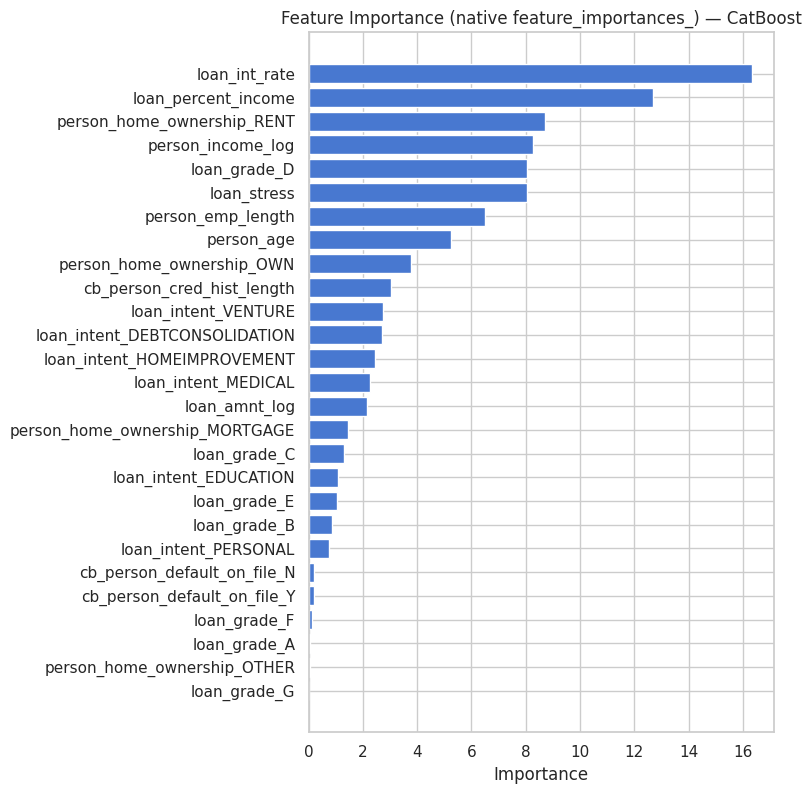


Saved model + threshold -> artifacts/loan_model.joblib


In [635]:
# FEATURE IMPORTANCE (native if available; else permutation)
def plot_feature_importance(trained_pipeline: Pipeline, X_fit: pd.DataFrame, num_cols, cat_cols):
    importances = None
    method = None

    # get transformed feature names
    prep = trained_pipeline.named_steps["prep"]
    # Build names from transformers
    num_names = list(num_cols)
    # OHE categories
    cat_names = []
    try:
        ohe = prep.named_transformers_["cat"].named_steps["ohe"]
        ohe_names = list(ohe.get_feature_names_out(cat_cols))
        cat_names = ohe_names
    except Exception:
        pass
    feat_names = num_names + cat_names

    # Try native feature_importances_ from final estimator
    clf = trained_pipeline.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        importances = np.asarray(clf.feature_importances_, dtype=float)
        method = "native feature_importances_"
    elif hasattr(clf, "get_booster"):  # XGB
        try:
            booster = clf.get_booster()
            gain = booster.get_score(importance_type="gain")
            # Map from f0.. to positions
            importances = np.zeros(len(feat_names), dtype=float)
            for i in range(len(feat_names)):
                importances[i] = gain.get(f"f{i}", 0.0)
            method = "XGB gain"
        except Exception:
            pass

    # Permutation fallback (slower)
    if importances is None or len(importances) != len(feat_names):
        pi = permutation_importance(trained_pipeline, X_fit, y_train, n_repeats=5, random_state=42, n_jobs=-1)
        importances = pi.importances_mean
        method = "permutation importance"

    # Plot
    order = np.argsort(importances)[::-1]
    names_sorted = [feat_names[i] for i in order]
    vals_sorted = importances[order]

    plt.figure(figsize=(8, max(4, len(names_sorted) * 0.3)))
    plt.barh(range(len(names_sorted)), vals_sorted)
    plt.gca().invert_yaxis()
    plt.yticks(range(len(names_sorted)), names_sorted)
    plt.xlabel("Importance")
    plt.title(f"Feature Importance ({method}) — {best_name}")
    plt.tight_layout()
    plt.show()

plot_feature_importance(best_pipe, X_train, num_cols, cat_cols)


# SAVE ARTIFACTS
os.makedirs("artifacts", exist_ok=True)
joblib.dump({"model": best_pipe, "threshold": best_thresh, "num_cols": num_cols, "cat_cols": cat_cols}, "artifacts/loan_model.joblib")
print("\nSaved model + threshold -> artifacts/loan_model.joblib")

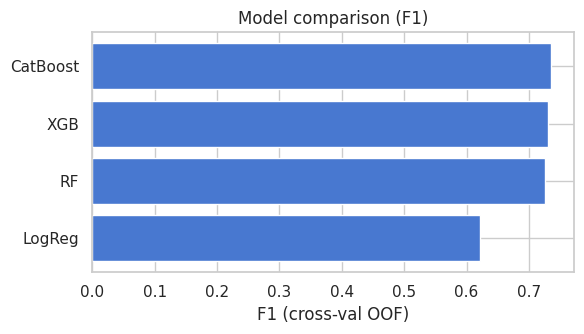

In [636]:
fig, ax = plt.subplots(figsize=(6, 3.5))
order = np.argsort(cv_df['f1'].values)
ax.barh(range(len(cv_df)), cv_df['f1'].values[order])
ax.set_yticks(range(len(cv_df)))
ax.set_yticklabels(cv_df['name'].values[order])
ax.set_xlabel('F1 (cross-val OOF)')
ax.set_title('Model comparison (F1)')
plt.tight_layout()
plt.show()


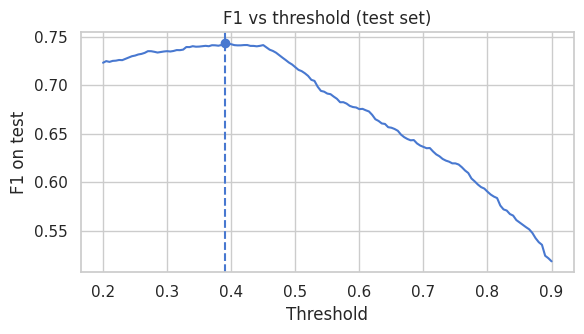

In [637]:
ts = np.linspace(0.2, 0.9, 141)
f1s = [f1_score(y_test, (proba_test >= t).astype(int)) for t in ts]

plt.figure(figsize=(6,3.5))
plt.plot(ts, f1s)
plt.axvline(best_thresh, linestyle='--')
plt.scatter([best_thresh], [f1_score(y_test, (proba_test >= best_thresh).astype(int))])
plt.xlabel('Threshold')
plt.ylabel('F1 on test')
plt.title('F1 vs threshold (test set)')
plt.tight_layout()
plt.show()


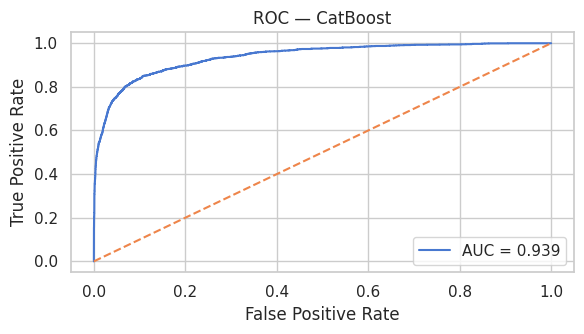

In [638]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure(figsize=(6,3.5))
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()


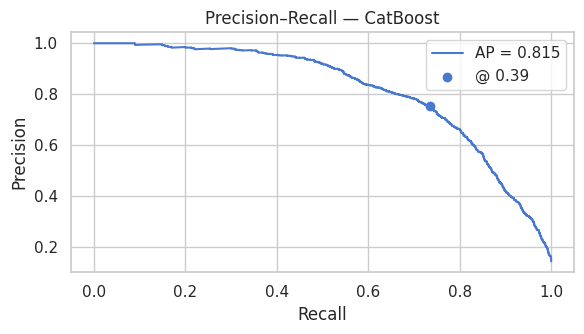

In [639]:
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
plt.figure(figsize=(6,3.5))
plt.plot(rec, prec, label=f'AP = {ap:.3f}')
plt.scatter([0.734], [0.752], marker='o', label=f'@ {best_thresh:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision–Recall — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()


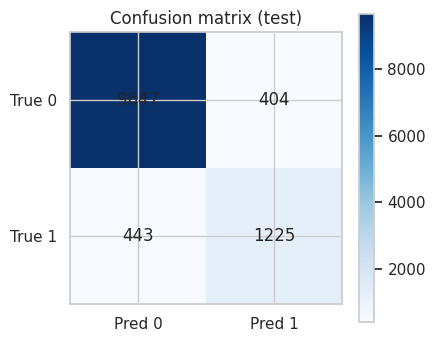

In [640]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4.5,3.8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for (i,j),v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
plt.title('Confusion matrix (test)')
plt.tight_layout()
plt.show()
